# ADCP AEP Estimation (PCU + IEC Bin-Sum)

This notebook estimates Annual Energy Production (AEP) from depth-dependent ADCP data using principal component velocity (PCU) and the IEC bin-sum method. 

### Inputs / User Parameters

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math
from datetime import datetime
from scipy.interpolate import interp1d

In [2]:
# File inputs
DATA_FILE = "depthDep_ADCPdata.csv"
POWER_CURVE_FILE = "power_curve_generated.csv"

# ADCP configuration
UNITS = "mm/s"  # or "m/s"
N_BINS = 49
HUB_BIN = 29  # 1-based index
BIN_WIDTH = 0.1  # m/s
MAX_ABS_SPEED_FILTER = 6.0  # m/s

# Turbine parameters (optional)
PRATED_KW = 110  # optional, set None if unknown
CUT_IN = 0.4  # optional
CUT_OUT = 3.2  # optional
RATED_SPEED = 1.5  # optional

# PCU sign convention
FLIP_PCU_TO_MAKE_FLOOD_POSITIVE = False
FLOOD_WINDOW = None  # tuple of (start_datetime, end_datetime) strings, or None

# Analysis options
USE_DEPTH_AVERAGE_FOR_PCA = True
PCA_BIN_RANGE = None  # (start_bin, end_bin) or None for all bins

# Optional annual scaling for partial datasets
SCALE_PERIOD_TO_ANNUAL = False


### Load and Parse ADCP Data

In [3]:
# Load ADCP data
df = pd.read_csv(DATA_FILE)

# Display basic info
print(f"Loaded ADCP data: {df.shape}")
print(f"Columns: {list(df.columns[:10])}...")
print(f"\nFirst few rows:")
print(df.head())

Loaded ADCP data: (16543, 198)
Columns: ['DateTime', 'Bin #:', '1', '1.1', '1.2', '1.3', '2', '2.1', '2.2', '2.3']...

First few rows:
              DateTime  Bin #:     1  1.1  1.2     1.3     2  2.1  2.2  \
0                  NaN     NaN   Eas  Nor  Mag     NaN   Eas  Nor  Mag   
1  2024-10-23 09:00:00     NaN    11   -7   13  117.47    12   -6   13   
2  2024-10-23 09:10:00     NaN   -88  -55  104  232.47   -82  -52   97   
3  2024-10-23 09:20:00     NaN  -181  -67  193  244.47  -171  -84  191   
4  2024-10-23 09:30:00     NaN  -243  -61  251  250.47  -246  -46  250   

      2.3  ... 47.2 47.3   48  48.1 48.2 48.3   49  49.1 49.2 49.3  
0     NaN  ...  Mag  NaN  Eas   Nor  Mag  NaN  Eas   Nor  Mag  NaN  
1  111.47  ...  NaN  NaN  NaN   NaN  NaN  NaN  NaN   NaN  NaN  NaN  
2  232.47  ...  NaN  NaN  NaN   NaN  NaN  NaN  NaN   NaN  NaN  NaN  
3  238.47  ...  NaN  NaN  NaN   NaN  NaN  NaN  NaN   NaN  NaN  NaN  
4  253.47  ...  NaN  NaN  NaN   NaN  NaN  NaN  NaN   NaN  NaN  NaN  

[5 ro

C:\Users\hseyyedzadeh\AppData\Local\Temp\ipykernel_23260\2176221651.py:2: DtypeWarning: Columns (2,3,4,6,7,8,10,11,12,14,15,16,18,19,20,22,23,24,26,27,28,30,31,32,34,35,36,38,39,40,42,43,44,46,47,48,50,51,52,54,55,56,58,59,60,62,63,64,66,67,68,70,71,72,74,75,76,78,79,80,82,83,84,86,87,88,90,91,92,94,95,96,98,99,100,102,103,104,106,107,108,110,111,112,114,115,116,118,119,120,122,123,124,126,127,128,130,131,132,134,135,136,138,139,140,142,143,144,146,147,148,150,151,152,154,155,156,158,159,160,162,163,164,166,167,168,170,171,172,174,175,176,178,179,180,182,183,184,186,187,188,190,191,192,194,195,196) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_FILE)


### Extract Depth Bin Information

In [4]:
# Extract bin numbers (every 4th column starting from column 2)
# Column structure: DateTime, Label, Bin1_Eas, Bin1_Nor, Bin1_Mag, Bin1_Dir, Bin2_Eas, ...
bin_cols = []
for i in range(2, len(df.columns), 4):  # Start at column 2, step by 4
    if i < len(df.columns):
        bin_cols.append(df.columns[i])

print(f"Found {len(bin_cols)} depth bins")
print(f"Bin columns (first 10): {bin_cols[:10]}")
print(f"Total columns in dataset: {len(df.columns)}")

# Define VALID_BINS for downstream extraction logic
def _parse_bin_number(col_name):
    m = re.match(r"\s*(\d+)", str(col_name))
    return int(m.group(1)) if m else None

bin_numbers = [n for n in (_parse_bin_number(c) for c in bin_cols) if n is not None]
bin_numbers = sorted(set(bin_numbers))
if len(bin_numbers) == 0:
    # Fallback to user-specified N_BINS
    VALID_BINS = list(range(1, int(N_BINS) + 1))
else:
    VALID_BINS = bin_numbers

print(f"VALID_BINS (count={len(VALID_BINS)}): {VALID_BINS[0]}..{VALID_BINS[-1]}")

Found 49 depth bins
Bin columns (first 10): ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Total columns in dataset: 198
VALID_BINS (count=49): 1..49


### Create Depth Mapping for ADCP Bins
Map bin numbers to depths in meters. ADCP starts at 1.67m with 0.5m intervals. Use bins 1-44 (1.67m to 23.17m);

In [5]:
# Create bin-to-depth mapping
def bin_to_depth(bin_number):
    """Convert bin number to depth in meters"""
    return 1.67 + (bin_number - 1) * 0.5

# Create depth mapping dictionary
depth_mapping = {}
for bin_num in range(1, 50):  # Bins 1 to 49 (keeping full mapping for reference)
    depth_mapping[bin_num] = bin_to_depth(bin_num)

# Valid bins for analysis (for excluding bins 45-49, VALID_BINS = list(range(1, 45)))
VALID_BINS = list(range(1, 50))

print("Depth mapping (first 10 bins):")
for bin_num in range(1, 11):
    print(f"  Bin {bin_num}: {depth_mapping[bin_num]:.2f} m")

print(f"  ...")
print(f"  Bin 44: {depth_mapping[44]:.2f} m (last bin used)")
#print(f"  Bin 45-49: {depth_mapping[45]:.2f}-{depth_mapping[49]:.2f} m (excluded due to significant deviation)")
print(f"\nUsing {len(VALID_BINS)} bins for analysis")

Depth mapping (first 10 bins):
  Bin 1: 1.67 m
  Bin 2: 2.17 m
  Bin 3: 2.67 m
  Bin 4: 3.17 m
  Bin 5: 3.67 m
  Bin 6: 4.17 m
  Bin 7: 4.67 m
  Bin 8: 5.17 m
  Bin 9: 5.67 m
  Bin 10: 6.17 m
  ...
  Bin 44: 23.17 m (last bin used)

Using 49 bins for analysis


### Load Power Curve
Load the turbine power curve with columns: speed_mps, cp_used, rpm_used, power_kw

In [6]:
def load_power_curve(path):
    """
    Load turbine power curve from CSV.
    Expected columns: speed_mps, cp_used, rpm_used, power_kw
    """
    pc = pd.read_csv(path)
    
    # Validate required columns
    required_cols = ['speed_mps', 'power_kw']
    for col in required_cols:
        if col not in pc.columns:
            raise ValueError(f'Power curve must have column: {col}')
    
    # Optional columns
    if 'cp_used' in pc.columns:
        print(f"Power curve includes Cp data")
    if 'rpm_used' in pc.columns:
        print(f"Power curve includes RPM data")
    
    # Keep only speed and power for interpolation
    pc_clean = pc[['speed_mps', 'power_kw']].dropna()
    
    print(f"Loaded power curve: {len(pc_clean)} points")
    print(f"Speed range: {pc_clean['speed_mps'].min():.2f} - {pc_clean['speed_mps'].max():.2f} m/s")
    print(f"Power range: {pc_clean['power_kw'].min():.2f} - {pc_clean['power_kw'].max():.2f} kW")
    
    return pc_clean

# Load power curve
pc = load_power_curve(POWER_CURVE_FILE)
pc.head()

Power curve includes Cp data
Power curve includes RPM data
Loaded power curve: 30 points
Speed range: 0.20 - 4.00 m/s
Power range: 0.16 - 110.00 kW


,speed_mps,power_kw
0,0.2000,0.158512
1,0.3310,1.308247
2,0.4621,3.490215
3,0.5931,7.457988
4,0.7241,14.003104


### Parse velocities into u(t,bin), v(t,bin)

This section converts the wide ADCP table into 2D arrays:

- `u[t, b]`: East velocity (m/s) for bin `b`
- `v[t, b]`: North velocity (m/s) for bin `b`

It is robust to columns like `1 Eas`, `1 Nor`, ... or `Bin 1 Eas`, etc.


In [7]:
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"DATA_FILE not found: {DATA_FILE}\n"
        "Update DATA_FILE to the path of your ADCP CSV and rerun."
    )

# ---- datetime parsing ----
# Try common datetime column names; fall back to first column.
dt_col_candidates = [c for c in df.columns if c.strip().lower() in ["datetime","date time","date_time","time","timestamp","date"]]
dt_col = dt_col_candidates[0] if dt_col_candidates else df.columns[0]

df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")
df = df.dropna(subset=[dt_col]).sort_values(dt_col).reset_index(drop=True)

print(f"Using datetime column: {dt_col}")
print(f"Time range: {df[dt_col].min()}  to  {df[dt_col].max()}")
print(f"Rows after datetime cleaning: {len(df)}")

# ---- velocity unit conversion ----
units = UNITS.lower().strip().replace(" ", "")
if units in ["cm/s", "cmps", "cm_s"]:
    unit_scale = 0.01
elif units in ["mm/s", "mmps", "mm_s"]:
    unit_scale = 0.001
else:
    unit_scale = 1.0

# ---- Direct column indexing based on ADCP structure ----
# Column structure: DateTime, Label, Bin1_Eas, Bin1_Nor, Bin1_Mag, Bin1_Dir, Bin2_Eas, ...
# For bin N (1-based):
#   Eas column index: 2 + (N-1)*4
#   Nor column index: 3 + (N-1)*4

def get_bin_columns(bin_num):
    """Get column indices for a given bin number (1-based)"""
    eas_idx = 2 + (bin_num - 1) * 4
    nor_idx = 3 + (bin_num - 1) * 4
    return eas_idx, nor_idx

# Use VALID_BINS from the depth mapping cell
bins_use = []
for b in VALID_BINS:
    eas_idx, nor_idx = get_bin_columns(b)
    # Check if columns exist
    if eas_idx < len(df.columns) and nor_idx < len(df.columns):
        bins_use.append(b)

if len(bins_use) == 0:
    raise ValueError(
        f"Could not find valid columns for bins. "
        f"DataFrame has {len(df.columns)} columns, expected at least {2 + 44*4} columns for 44 bins."
    )

print(f"Bins used for analysis: {bins_use[0]}..{bins_use[-1]}  (count={len(bins_use)})")

# Build arrays [time, bin]
t = df[dt_col].to_numpy()
u = np.full((len(df), len(bins_use)), np.nan, dtype=float)
v = np.full((len(df), len(bins_use)), np.nan, dtype=float)

for j, b in enumerate(bins_use):
    eas_idx, nor_idx = get_bin_columns(b)
    u_col = df.columns[eas_idx]
    v_col = df.columns[nor_idx]
    u[:, j] = pd.to_numeric(df[u_col], errors="coerce").to_numpy() * unit_scale
    v[:, j] = pd.to_numeric(df[v_col], errors="coerce").to_numpy() * unit_scale

# Filter out extreme values (optional)
speed_mag = np.sqrt(u**2 + v**2)
mask_bad = speed_mag > MAX_ABS_SPEED_FILTER
u[mask_bad] = np.nan
v[mask_bad] = np.nan

print(f"Valid samples (u,v) after filtering: {np.isfinite(u).sum()} / {u.size} (u), {np.isfinite(v).sum()} / {v.size} (v)")

Using datetime column: DateTime
Time range: 2024-10-23 09:00:00  to  2025-02-15 07:05:00
Rows after datetime cleaning: 16542
Bins used for analysis: 1..49  (count=49)
Valid samples (u,v) after filtering: 761341 / 810558 (u), 761341 / 810558 (v)


### Compute principal axis and PCU(t,bin)

We compute the principal axis using a covariance-based PCA on depth-averaged (or selected-bin averaged) velocities, then project each bin’s velocity vector onto that axis:

$$
PCU(t, z) = u(t,z)\,e_x + v(t,z)\,e_y
$$


In [8]:
# Choose bins for PCA if requested
if PCA_BIN_RANGE is not None:
    b0, b1 = PCA_BIN_RANGE
    # convert 1-based bin numbers to indices in bins_use
    pca_bins = [b for b in bins_use if (b0 <= b <= b1)]
else:
    pca_bins = bins_use

pca_idx = [bins_use.index(b) for b in pca_bins]

u_pca = u[:, pca_idx]
v_pca = v[:, pca_idx]

# Depth-avg velocity for PCA
u_bar = np.nanmean(u_pca, axis=1)
v_bar = np.nanmean(v_pca, axis=1)

# Drop times with no valid velocity
good = np.isfinite(u_bar) & np.isfinite(v_bar)
u0 = u_bar[good] - np.nanmean(u_bar[good])
v0 = v_bar[good] - np.nanmean(v_bar[good])

C = np.cov(np.vstack([u0, v0]))
eigvals, eigvecs = np.linalg.eigh(C)
e1 = eigvecs[:, np.argmax(eigvals)]  # principal axis unit vector (east,north)

ex, ey = float(e1[0]), float(e1[1])

# Axis angle conventions
angle_from_east_deg = (math.degrees(math.atan2(ey, ex)) + 360) % 360  # CCW from East
bearing_from_north_deg = (90 - angle_from_east_deg) % 360            # clockwise from North

print(f"Principal axis unit vector (east,north) = ({ex:.4f}, {ey:.4f})")
print(f"Principal axis angle: {angle_from_east_deg:.2f}° CCW from East")
print(f"Principal axis bearing: {bearing_from_north_deg:.2f}° clockwise from North")

# Project onto axis to get PCU(t,bin)
pcu = u*ex + v*ey  # shape [time, bins]

# Optional flip to make flood positive, if you supply a FLOOD_WINDOW
if FLIP_PCU_TO_MAKE_FLOOD_POSITIVE and (FLOOD_WINDOW is not None):
    start_str, end_str = FLOOD_WINDOW
    start_dt = pd.to_datetime(start_str)
    end_dt = pd.to_datetime(end_str)
    win = (t >= start_dt.to_datetime64()) & (t <= end_dt.to_datetime64())
    mean_in_window = np.nanmean(pcu[win, :])
    if np.isfinite(mean_in_window) and mean_in_window < 0:
        pcu = -pcu
        print("Flipped PCU sign so that mean PCU in FLOOD_WINDOW is positive.")


Principal axis unit vector (east,north) = (-0.9672, -0.2539)
Principal axis angle: 194.71° CCW from East
Principal axis bearing: 255.29° clockwise from North


### Build turbine-relevant velocity time series

We use hub-bin PCU speed (m/s): `V_hub(t) = |PCU(t, hub_bin)|`

This becomes the input to IEC binning and AEP.


In [9]:

def bin_to_index(bin_number: int) -> int:
    """Convert a 1-based bin number to index in bins_use list."""
    if bin_number not in bins_use:
        raise ValueError(f"Requested bin {bin_number} is not in bins_use.")
    return bins_use.index(bin_number)

# Hub bin speed
hub_idx = bin_to_index(HUB_BIN)
V_hub = np.abs(pcu[:, hub_idx])

def summarize_velocity(name, V):
    print(f"{name}: valid={np.isfinite(V).sum()}  min={np.nanmin(V):.3f}  mean={np.nanmean(V):.3f}  p95={np.nanpercentile(V,95):.3f}  max={np.nanmax(V):.3f}")

summarize_velocity("V_hub", V_hub)


V_hub: valid=16542  min=0.000  mean=0.755  p95=1.273  max=1.625


### IEC binning and AEP calculation

We compute a velocity histogram with bin width `BIN_WIDTH` and then apply:

$$
AEP = 8760 \hspace{1mm} \text{TECA} \sum_i f_i \, P(V_i)
$$

We also compute energy over the measured period (kWh) using the dataset duration.


In [10]:
# Power curve interpolator (speed->power)
pc = pc.sort_values("speed_mps")
p_interp = interp1d(pc["speed_mps"].to_numpy(), pc["power_kw"].to_numpy(),
                    bounds_error=False, fill_value=(0.0, float(pc["power_kw"].iloc[-1])))

def iec_aep_from_velocity(V, bin_width=0.1):
    V = V[np.isfinite(V)]
    if len(V) == 0:
        raise ValueError("No valid velocities provided.")

    vmax = float(np.nanmax(V))
    vmax = math.ceil(vmax / bin_width) * bin_width

    edges = np.arange(0.0, vmax + bin_width, bin_width)
    centers = 0.5*(edges[:-1] + edges[1:])
    counts, _ = np.histogram(V, bins=edges)
    f = counts / counts.sum()

    P = p_interp(centers)  # kW
    P = np.clip(P, 0, None)

    # Annual energy (kWh/year)
    Nh = 8760.0
    AEP = Nh * np.sum(P * f)

    # Period energy (kWh over record)
    # Estimate duration hours from timestamps
    t0 = pd.to_datetime(t[0])
    t1 = pd.to_datetime(t[-1])
    hours = (t1 - t0).total_seconds()/3600.0
    E_period = hours * np.sum(P * f)

    if SCALE_PERIOD_TO_ANNUAL:
        AEP_scaled = E_period * (8760.0 / hours)
    else:
        AEP_scaled = None

    detail = pd.DataFrame({
        "V_center_mps": centers,
        "prob_f": f,
        "P_kw": P,
        "kWh_per_year_bin": Nh * P * f
    })
    return AEP, E_period, AEP_scaled, detail

AEP_hub, E_hub, AEP_hub_scaled, detail_hub = iec_aep_from_velocity(V_hub, BIN_WIDTH)

print("Hub-bin:")
print(f"  AEP (bin-sum, 8760h) = {AEP_hub:,.1f} kWh/year")
print(f"  Energy over record   = {E_hub:,.1f} kWh  (duration used from timestamps)")
if AEP_hub_scaled is not None:
    print(f"  Scaled-to-annual AEP = {AEP_hub_scaled:,.1f} kWh/year  (assumes stationarity)")
if PRATED_KW is not None:
    cf = AEP_hub / (PRATED_KW * 8760.0)
    print(f"  Capacity factor      = {cf:.3f}")


Hub-bin:
  AEP (bin-sum, 8760h) = 235,173.1 kWh/year
  Energy over record   = 74,044.2 kWh  (duration used from timestamps)
  Capacity factor      = 0.244


### Plots and exports

We plot velocity PDFs and the power curve, and export bin-by-bin contributions for traceability.


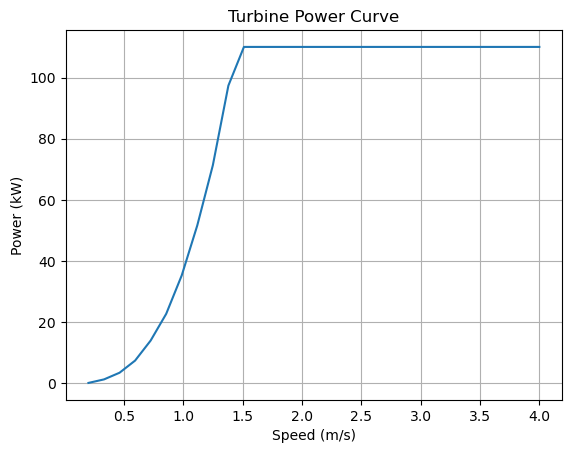

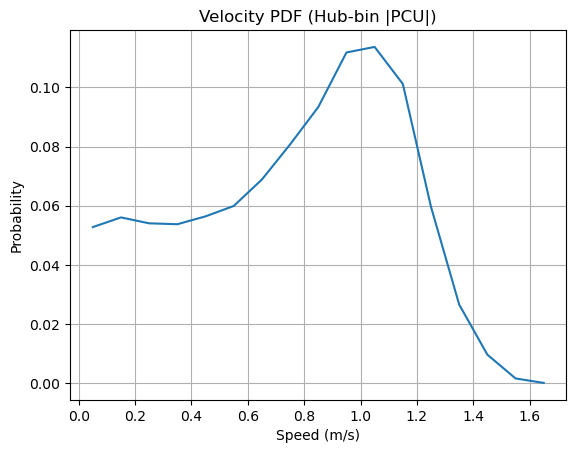

Exported:
 - aep_bins_hub.csv


In [14]:

import matplotlib.pyplot as plt

def plot_velocity_pdf(detail, title):
    plt.figure()
    plt.plot(detail["V_center_mps"], detail["prob_f"])
    plt.xlabel("Speed (m/s)")
    plt.ylabel("Probability")
    plt.title(title)
    plt.grid(True)

def plot_power_curve(pc):
    plt.figure()
    plt.plot(pc["speed_mps"], pc["power_kw"])
    plt.xlabel("Speed (m/s)")
    plt.ylabel("Power (kW)")
    plt.title("Turbine Power Curve")
    plt.grid(True)

plot_power_curve(pc)
plot_velocity_pdf(detail_hub, "Velocity PDF (Hub-bin |PCU|)")

plt.show()

# Export details
# detail_hub.to_csv("aep_bins_hub.csv", index=False)

print("Exported:")
print(" - aep_bins_hub.csv")


### IEC ebb/flood bin probabilities (unconditional)

Compute unconditional IEC bin probabilities separated by flow direction using a **signed** along-channel velocity time series (PCU).

- Flood if `U_signed > 0`
- Ebb if `U_signed < 0`
- Speed for binning: `U_speed = |U_signed|`

We time-weight by the record timestep (computed from the parsed datetime column), so that:

$$\sum_i f_{\text{ebb},i} + \sum_i f_{\text{flood},i} = 1$$


Signed velocity source: pcu_hub
Valid weighted duration used: 2,758.25 hours
Flood fraction (time): 0.5002
Ebb fraction (time):   0.4998
Sum check: (f_flood.sum + f_ebb.sum) = 1.000000
Saved: site_probabilities_ebb_flood.csv


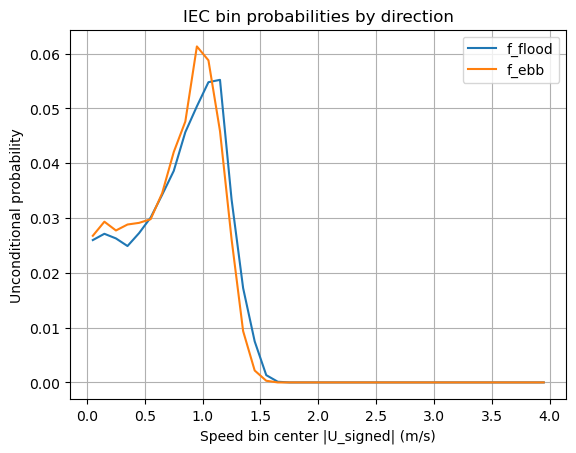

In [12]:
# ---- user settings ----
UMAX_USER = 4             # set float (m/s) to override, else auto from data
UMAX_QUANTILE = 99.9         # percentile of U_speed used when UMAX_USER is None
EXPORT_CSV = "site_probabilities_ebb_flood.csv"

# ---- signed along-channel velocity at hub bin (PCU) ----
U_signed = pcu[:, hub_idx]
source_label = "pcu_hub"

# ---- classify ebb/flood & define speed ----
U_speed = np.abs(U_signed)
is_flood = U_signed > 0
is_ebb = U_signed < 0

# ---- time weights from parsed datetime column ----
# required implementation pattern (seconds)
t = pd.to_datetime(df[dt_col]).astype("int64") / 1e9  # seconds
t = t.to_numpy(dtype=float)
dt = np.diff(t, prepend=t[0])
dt[0] = dt[1] if len(dt) > 1 else 0.0
dt = np.maximum(dt, 0.0)

# ---- filtering (NaNs + speed cap) ----
valid = np.isfinite(U_speed) & np.isfinite(dt) & (dt > 0) & (U_speed <= MAX_ABS_SPEED_FILTER)
U_speed_v = U_speed[valid]
U_signed_v = U_signed[valid]
dt_v = dt[valid]
is_flood_v = U_signed_v > 0
is_ebb_v = U_signed_v < 0

if U_speed_v.size == 0:
    raise ValueError("No valid samples after filtering for IEC ebb/flood probabilities.")

# ---- bin edges & centers ----
if UMAX_USER is None:
    umax_data = float(np.nanpercentile(U_speed_v, UMAX_QUANTILE))
    Umax = min(umax_data, float(MAX_ABS_SPEED_FILTER))
else:
    Umax = float(UMAX_USER)
Umax = max(Umax, 0.0)
Umax = math.ceil(Umax / BIN_WIDTH) * BIN_WIDTH
if Umax <= 0:
    raise ValueError("Computed Umax <= 0; check velocity data and filters.")

edges = np.arange(0.0, Umax + BIN_WIDTH, BIN_WIDTH)
centers = 0.5 * (edges[:-1] + edges[1:])
U_lo = edges[:-1]
U_hi = edges[1:]

# ---- time-weighted histograms (seconds in bin) ----
sec_total = float(np.sum(dt_v))
sec_flood_bins, _ = np.histogram(U_speed_v[is_flood_v], bins=edges, weights=dt_v[is_flood_v])
sec_ebb_bins, _ = np.histogram(U_speed_v[is_ebb_v], bins=edges, weights=dt_v[is_ebb_v])

f_flood = sec_flood_bins / sec_total
f_ebb = sec_ebb_bins / sec_total
f_total = f_flood + f_ebb

# ---- checks ----
flood_frac = float(np.sum(dt_v[is_flood_v]) / sec_total)
ebb_frac = float(np.sum(dt_v[is_ebb_v]) / sec_total)
print(f"Signed velocity source: {source_label}")
print(f"Valid weighted duration used: {sec_total/3600.0:,.2f} hours")
print(f"Flood fraction (time): {flood_frac:.4f}")
print(f"Ebb fraction (time):   {ebb_frac:.4f}")
print(f"Sum check: (f_flood.sum + f_ebb.sum) = {(f_flood.sum() + f_ebb.sum()):.6f}")

# ---- export ----
out = pd.DataFrame({
    "U_lo_mps": U_lo,
    "U_hi_mps": U_hi,
    "U_center_mps": centers,
    "f_flood": f_flood,
    "f_ebb": f_ebb,
    "f_total": f_total,
})
out.to_csv(EXPORT_CSV, index=False)
print(f"Saved: {EXPORT_CSV}")

# ---- quick plot ----
plt.figure()
plt.plot(centers, f_flood, label="f_flood")
plt.plot(centers, f_ebb, label="f_ebb")
plt.xlabel("Speed bin center |U_signed| (m/s)")
plt.ylabel("Unconditional probability")
plt.title("IEC bin probabilities by direction")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
# Farm AEP (scale single-turbine results)
N_TURBINES = 24

def scale_aep_to_farm(name, AEP, E_period, AEP_scaled, n_turbines):
    farm_aep = AEP * n_turbines
    farm_e_period = E_period * n_turbines
    farm_aep_scaled = AEP_scaled * n_turbines if AEP_scaled is not None else None
    print(f"{name} farm AEP for {n_turbines} turbines:")
    print(f"  AEP (bin-sum, 8760h) = {farm_aep:,.1f} kWh/year")
    print(f"  Energy over record   = {farm_e_period:,.1f} kWh")
    if farm_aep_scaled is not None:
        print(f"  Scaled-to-annual AEP = {farm_aep_scaled:,.1f} kWh/year")
    if PRATED_KW is not None:
        cf = farm_aep / (PRATED_KW * n_turbines * 8760.0)
        print(f"  Capacity factor      = {cf:.3f}")
    print("")

scale_aep_to_farm("Hub-bin", AEP_hub, E_hub, AEP_hub_scaled, N_TURBINES)

Hub-bin farm AEP for 24 turbines:
  AEP (bin-sum, 8760h) = 5,644,153.8 kWh/year
  Energy over record   = 1,777,060.1 kWh
  Capacity factor      = 0.244

